# Preprocessing Data

In [1]:
# import
import os
import re
import csv
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from io import StringIO
from urllib.request import urlopen

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [2]:
# Data path
true_path = r'A:/VNU - UET/code/personal projects/ML/Data/True.csv'
fake_path = r'A:/VNU - UET/code/personal projects/ML/Data/Fake.csv'

In [3]:
# Read csv
data_true = pd.read_csv(true_path)
data_fake = pd.read_csv(fake_path)

In [4]:
data_true['class'] = 1
data_fake['class'] = 0

In [5]:
data = pd.concat([data_true, data_fake], axis= 0)
data.sample(5)

,title,text,subject,date,class
11262,BREAKING: D.C. Driver Plows Into Capitol Polic...,It happened around 9:30 a.m. at the 100 block ...,politics,"Mar 29, 2017",0
5672,WATCH: The NRA Just Got Caught Desecrating A ...,The NRA claims to care about our military vete...,News,"June 29, 2016",0
11926,Melania's birth country Slovenia sees strong t...,"LJUBLJANA (Reuters) - Slovenia, birth country ...",worldnews,"December 19, 2017",1
8499,House Speaker Ryan easily wins primary: media,MILWAUKEE (Reuters) - U.S. House of Representa...,politicsNews,"August 9, 2016",1
12295,GREEN PARTY DOLT Struggles To Explain Wisconsi...,IAN JACKSON: People have been slightly concern...,politics,"Nov 26, 2016",0


In [6]:
# Information about data
print("Thông tin dữ liệu:")
display(data.info())

print("\n5 dòng đầu:")
display(data.head())

print("\nTên cột:")
print(data.columns.tolist())

print("\nSố lượng giá trị thiếu:")
print(data.isna().sum())


Thông tin dữ liệu:
<class 'pandas.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   class    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.6 MB


None


5 dòng đầu:


,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1



Tên cột:
['title', 'text', 'subject', 'date', 'class']

Số lượng giá trị thiếu:
title      0
text       0
subject    0
date       0
class      0
dtype: int64


In [7]:
# pre clean data
data['content'] = data['title'] + ' ' +data['text']
data.drop(['title', 'subject', 'date', 'text'], axis=1, inplace=True)
data.sample(5)

,class,content
17692,0,HOW CAN ANYONE TRUST THEM? TWITTER Admits To H...
17570,0,DEMOCRAT DERSHOWITZ Slaps Down Feinstein’s Eff...
21165,1,"Kenyan court scraps presidential vote, Kenyatt..."
8926,1,New rules give protesters more leeway at Repub...
13481,0,FUNNY FLASHBACK: “Donald Trump will NOT be the...


In [8]:

data = data.drop_duplicates(subset=['content']).reset_index(drop=True)

print("Số dòng sau khi xóa trùng:", len(data))

Số dòng sau khi xóa trùng: 39105


In [9]:
data.reset_index(inplace= True)
data.sample(5)

,index,class,content
8472,8472,1,"Trump would freeze new federal regulations, re..."
22348,22348,0,Sen. Heinrich Just Wiped The Floor Jeff Sessi...
10202,10202,1,Cuba breaks up weekly dissident march hours be...
35481,35481,0,HARVARD BULLIED INTO Dropping 80 Year Old “Rac...
1461,1461,1,U.S. civil liberties group to challenge Trump'...


In [10]:
data.drop(['index'], axis=1, inplace= True)
data.sample(5)

,class,content
11302,1,Russia's Lavrov says timing of Putin-Trump mee...
13910,1,U.S. calling Rohingya operation 'ethnic cleans...
17545,1,Suicide bombers attack Damascus police center:...
27856,0,Madeleine Albright Unleashes Blistering Attac...
25614,0,The GOP Just Revealed What They REALLY Think ...


In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+', '', text)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return ' '.join(tokens)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
data["content"] = data["content"].apply(preprocess_text)

In [13]:
data.sample(5)

,class,content
14987,1,countering trump china xi tout cooperation asi...
704,1,house committee pass sweeping tax bill washing...
4320,1,big win trump senate approves conservative cou...
13937,1,facing graft probe pakistan finance minister r...
22697,0,fbi tell trump go fck firing director force ca...


In [14]:
# slplit train and test.
x = data['content']
y = data['class']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size= 0.25,
    random_state= 42, stratify=y
)

In [15]:
label_names = {
    1 : 'True New',
    0 : 'Fake New'
}
print("Số mẫu train:", len(x_train))
print("Số mẫu test:", len(x_test))

print("\nPhân bố nhãn train:")
print(y_train.value_counts().sort_index().rename(index=label_names))
 
print("\nPhân bố nhãn test:")
print(y_test.value_counts().sort_index().rename(index=label_names))

Số mẫu train: 29328
Số mẫu test: 9777

Phân bố nhãn train:
class
Fake New    13431
True New    15897
Name: count, dtype: int64

Phân bố nhãn test:
class
Fake New    4477
True New    5300
Name: count, dtype: int64


# SVM Linear Algorithm


SVM Linear

In [16]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features= 20000,
        ngram_range= (1, 2),
        min_df=2, 
        max_df=0.95,
        sublinear_tf= True
    )),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
svm_pipeline.fit(x_train, y_train)

y_pred_svm = svm_pipeline.predict(x_test)

print("Result of SVM Linear:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Fake', 'Real'],
    zero_division= 0,
    digits= 6
))

Result of SVM Linear:
              precision    recall  f1-score   support

        Fake   0.997985  0.995533  0.996757      4477
        Real   0.996234  0.998302  0.997267      5300

    accuracy                       0.997034      9777
   macro avg   0.997110  0.996917  0.997012      9777
weighted avg   0.997036  0.997034  0.997034      9777



Optimazing Model SVM with GridSearchCV

In [18]:
param_grid = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "svm__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Tham số tốt nhất:")
print(grid_search.best_params_)

print("\nF1-score trung bình tốt nhất trên cross-validation:")
print(grid_search.best_score_)

best_svm_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tham số tốt nhất:
{'svm__C': 1, 'tfidf__max_features': 10000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

F1-score trung bình tốt nhất trên cross-validation:
0.9968270414936772


Evaluate model after optimazing

In [19]:
y_pred_best_svm = best_svm_model.predict(x_test)

svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
svm_precision = precision_score(y_test, y_pred_best_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_best_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_best_svm, zero_division=0)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)

print("\nResult:")
print(classification_report(
    y_test,
    y_pred_best_svm,
    target_names=["Fake", "Real"],
    zero_division=0,
    digits=6
))

Accuracy: 0.9971361358289864
Precision: 0.9962349397590361
Recall: 0.9984905660377359
F1-score: 0.9973614775725593

Result:
              precision    recall  f1-score   support

        Fake   0.998208  0.995533  0.996869      4477
        Real   0.996235  0.998491  0.997361      5300

    accuracy                       0.997136      9777
   macro avg   0.997222  0.997012  0.997115      9777
weighted avg   0.997139  0.997136  0.997136      9777



Confusion matrix

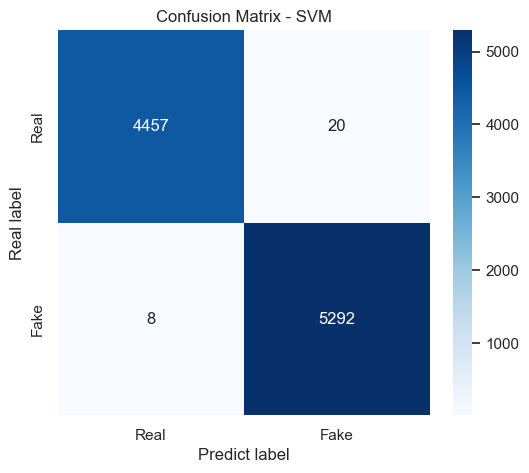

In [20]:
cm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

# Logistic Regression

In [21]:
logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('logistic', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(x_train, y_train)

y_pred_logistic = logistic_pipeline.predict(x_test)

print("Result of Logistic Regression:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Fake', 'Real'],
    zero_division=0,
    digits=6
))

Result of Logistic Regression:
              precision    recall  f1-score   support

        Fake   0.995494  0.987045  0.991252      4477
        Real   0.989135  0.996226  0.992668      5300

    accuracy                       0.992022      9777
   macro avg   0.992314  0.991636  0.991960      9777
weighted avg   0.992047  0.992022  0.992019      9777



Accuracy: 0.9920220926664621
Precision: 0.9891345073061072
Recall: 0.9962264150943396
F1-score: 0.9926677946982515


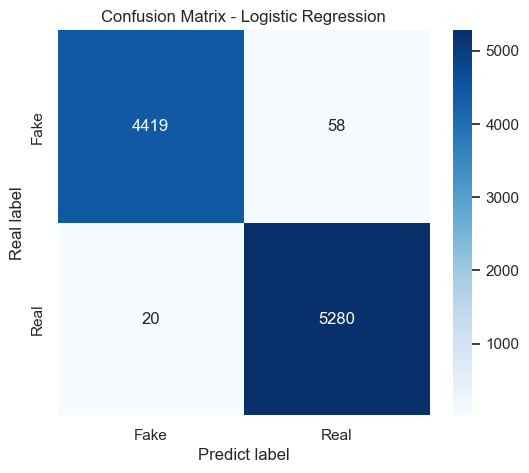

In [22]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

## Linear SVM - From Scratch

Ý tưởng chính:

- Đổi nhãn ban đầu `0/1` thành `-1/+1`.
- Tối ưu hàm mất mát Hinge Loss
- Cập nhật trọng số bằng Mini-batch Gradient Descent
- Dự đoán theo dấu của hàm quyết định `X @ w + b`.

- 0 = Fake News
- 1 = Real News

In [23]:
class LinearSVMFromScratch:
    def __init__(self, learning_rate=0.01, C=1.0, n_epochs=10, batch_size=512, random_state=42):
        self.learning_rate = learning_rate
        self.C = C
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.w = None
        self.b = 0.0
        self.loss_history = []

    def _convert_labels(self, y):
        """Chuyển nhãn 0/1 thành -1/+1 để phù hợp với công thức SVM."""
        y = np.asarray(y)
        return np.where(y == 1, 1, -1)

    def _compute_loss(self, X, y_signed):
        """Tính tổng loss = regularization + hinge loss."""
        margins = y_signed * (X @ self.w + self.b)
        hinge_loss = np.maximum(0, 1 - margins).mean()
        regularization_loss = 0.5 * np.dot(self.w, self.w)
        return regularization_loss + self.C * hinge_loss

    def fit(self, X, y, verbose=True):
        y_signed = self._convert_labels(y)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y_signed[batch_idx]

                margins = y_batch * (X_batch @ self.w + self.b)
                violations = margins < 1

                # Đạo hàm phần regularization: w
                w_grad = self.w.copy()
                b_grad = 0.0

                # Đạo hàm phần hinge loss đối với các điểm vi phạm margin
                if np.any(violations):
                    X_violate = X_batch[violations]
                    y_violate = y_batch[violations]

                    hinge_w_grad = X_violate.T @ y_violate
                    hinge_w_grad = np.asarray(hinge_w_grad).ravel()

                    w_grad -= self.C * hinge_w_grad / len(batch_idx)
                    b_grad -= self.C * np.sum(y_violate) / len(batch_idx)

                self.w -= self.learning_rate * w_grad
                self.b -= self.learning_rate * b_grad

            epoch_loss = self._compute_loss(X, y_signed)
            self.loss_history.append(epoch_loss)

            if verbose:
                print(f"Epoch {epoch + 1}/{self.n_epochs} - Loss: {epoch_loss:.6f}")

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, 0)


In [24]:
# Vector hóa văn bản riêng cho mô hình SVM from scratch.
# Giảm max_features xuống 5000 để mô hình tự code chạy nhanh hơn.
tfidf_svm_scratch = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_scratch = tfidf_svm_scratch.fit_transform(x_train)
X_test_scratch = tfidf_svm_scratch.transform(x_test)

svm_scratch = LinearSVMFromScratch(
    learning_rate=0.01,
    C=1.0,
    n_epochs=10,
    batch_size=512,
    random_state=RANDOM_STATE
)

svm_scratch.fit(X_train_scratch, y_train, verbose=True)

y_pred_svm_scratch = svm_scratch.predict(X_test_scratch)

print("Result of Linear SVM From Scratch:")
print(classification_report(
    y_test,
    y_pred_svm_scratch,
    target_names=['Fake', 'Real'],
    zero_division=0,
    digits=6
))

Epoch 1/10 - Loss: 0.993136
Epoch 2/10 - Loss: 0.988152
Epoch 3/10 - Loss: 0.983717
Epoch 4/10 - Loss: 0.979520
Epoch 5/10 - Loss: 0.975371
Epoch 6/10 - Loss: 0.971187
Epoch 7/10 - Loss: 0.967110
Epoch 8/10 - Loss: 0.962975
Epoch 9/10 - Loss: 0.958791
Epoch 10/10 - Loss: 0.954724
Result of Linear SVM From Scratch:
              precision    recall  f1-score   support

        Fake   0.000000  0.000000  0.000000      4477
        Real   0.542089  1.000000  0.703058      5300

    accuracy                       0.542089      9777
   macro avg   0.271044  0.500000  0.351529      9777
weighted avg   0.293860  0.542089  0.381120      9777



Accuracy: 0.5420885752275749
Precision: 0.5420885752275749
Recall: 1.0
F1-score: 0.7030576374610333


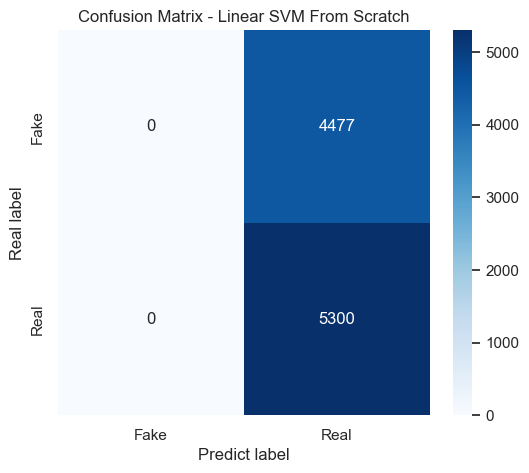

In [25]:
svm_scratch_accuracy = accuracy_score(y_test, y_pred_svm_scratch)
svm_scratch_precision = precision_score(y_test, y_pred_svm_scratch, zero_division=0)
svm_scratch_recall = recall_score(y_test, y_pred_svm_scratch, zero_division=0)
svm_scratch_f1 = f1_score(y_test, y_pred_svm_scratch, zero_division=0)

print("Accuracy:", svm_scratch_accuracy)
print("Precision:", svm_scratch_precision)
print("Recall:", svm_scratch_recall)
print("F1-score:", svm_scratch_f1)

cm_svm_scratch = confusion_matrix(y_test, y_pred_svm_scratch)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm_scratch,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Linear SVM From Scratch")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

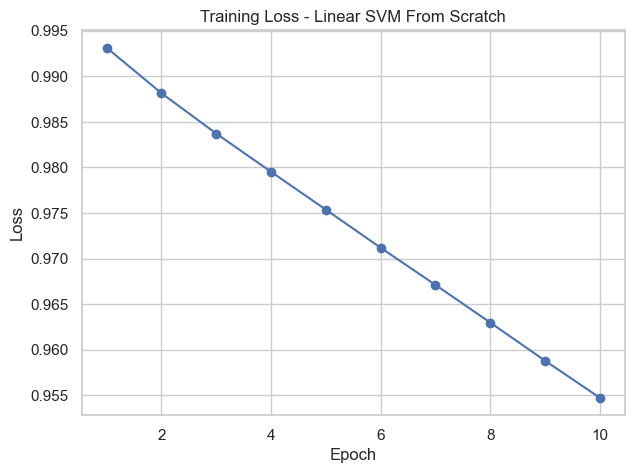

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(svm_scratch.loss_history) + 1), svm_scratch.loss_history, marker='o')
plt.title("Training Loss - Linear SVM From Scratch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# So sánh kết quả mô hình

In [31]:
comparison_results = pd.DataFrame([
    {
        "Model": "Linear SVM (library)",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1-score": svm_f1
    },
    {
        "Model": "Logistic Regression (library)",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-score": logistic_f1
    },
    {
        "Model": "Linear SVM (from scratch)",
        "Accuracy": svm_scratch_accuracy,
        "Precision": svm_scratch_precision,
        "Recall": svm_scratch_recall,
        "F1-score": svm_scratch_f1
    }
])

comparison_results

,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM (library),0.997136,0.996235,0.998491,0.997361
1,Logistic Regression (library),0.992022,0.989135,0.996226,0.992668
2,Linear SVM (from scratch),0.542089,0.542089,1.000000,0.703058


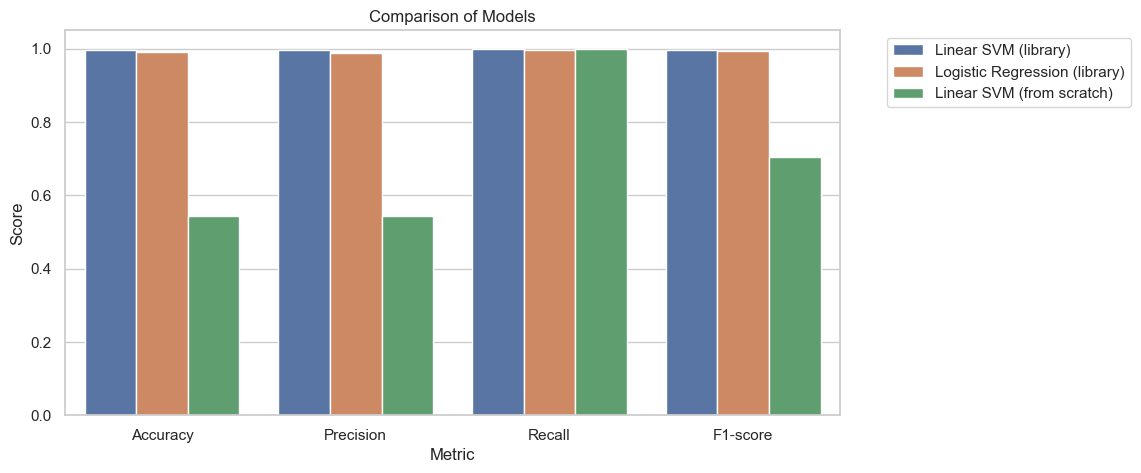

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_results.melt(id_vars="Model", var_name="Metric", value_name="Score"),
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Comparison of Models")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [35]:
# Lưu model SVM tốt nhất, gồm cả TF-IDF + LinearSVC
joblib.dump(best_svm_model, "svm_pipeline_model_1.jb")

print("Đã lưu model vào:svm_pipeline_model_1.jb")

Đã lưu model vào:svm_pipeline_model_1.jb


# Phân tích các mẫu dự đoán sai

In [ ]:
import re
import numpy as np
import pandas as pd
from IPython.display import display, HTML


# =========================
# 1. Tạo DataFrame chứa các mẫu dự đoán sai
# =========================

error_df = pd.DataFrame({
    "text": x_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_label": pd.Series(y_pred_best_svm).reset_index(drop=True)
})

# Chỉ lấy những mẫu mô hình dự đoán sai
error_df = error_df[error_df["true_label"] != error_df["pred_label"]].copy()

label_name = {
    0: "Fake News",
    1: "Real News"
}
print("0 = Fake News " \
"      1 = Real News")
print("\nTổng số mẫu dự đoán sai:", len(error_df))
print("\n5 mẫu đầu tiên trong", len(error_df),"mẫu sai là: ")
display(error_df.head())


# =========================
# 2. Hàm lấy từ/cụm từ làm mô hình nghiêng về nhãn đã dự đoán
# =========================

def get_vectorizer_and_classifier(pipeline_model):
    """
    Lấy TF-IDF vectorizer và classifier cuối cùng từ Pipeline.
    Dùng được cho Pipeline dạng:
    Pipeline([
        ('tfidf', TfidfVectorizer(...)),
        ('svm', LinearSVC(...))
    ])
    """

    tfidf = None

    for name, step in pipeline_model.named_steps.items():
        if hasattr(step, "get_feature_names_out") and hasattr(step, "transform"):
            tfidf = step
            break

    classifier = pipeline_model.steps[-1][1]

    return tfidf, classifier


def get_words_supporting_prediction(pipeline_model, text, predicted_label, top_n=8):
    """
    Lấy các từ/cụm từ trong văn bản làm mô hình nghiêng về nhãn predicted_label.

    Quy ước:
    0 = Fake News
    1 = Real News

    Với LinearSVC:
    - contribution dương thường nghiêng về class 1
    - contribution âm thường nghiêng về class 0
    """

    tfidf, classifier = get_vectorizer_and_classifier(pipeline_model)

    if tfidf is None or classifier is None:
        return []

    if not hasattr(classifier, "coef_"):
        return []

    X = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    coef = classifier.coef_[0]

    contributions = X.multiply(coef).toarray().ravel()
    nonzero_indices = X.nonzero()[1]

    classes = list(classifier.classes_)

    # Nếu mô hình dự đoán Real
    if predicted_label == classes[1]:
        candidates = [
            (feature_names[i], contributions[i])
            for i in nonzero_indices
            if contributions[i] > 0
        ]

    # Nếu mô hình dự đoán Fake
    else:
        candidates = [
            (feature_names[i], abs(contributions[i]))
            for i in nonzero_indices
            if contributions[i] < 0
        ]

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)

    return candidates[:top_n]


# =========================
# 3. Hàm phân tích nguyên nhân dự đoán sai
# =========================

# =========================
# TỰ ĐỘNG LẤY TỪ NGHIÊNG VỀ FAKE / REAL TỪ MODEL
# =========================

def extract_model_keywords(pipeline_model, top_n=30):
    """
    Tự động lấy các từ/cụm từ quan trọng nhất từ mô hình Linear SVM hoặc Logistic Regression.

    Quy ước:
    0 = Fake News
    1 = Real News

    Với mô hình nhị phân:
    - coef âm mạnh  -> nghiêng về class 0, tức Fake
    - coef dương mạnh -> nghiêng về class 1, tức Real
    """

    tfidf, classifier = get_vectorizer_and_classifier(pipeline_model)

    if tfidf is None or classifier is None:
        return set(), set()

    if not hasattr(classifier, "coef_"):
        return set(), set()

    feature_names = tfidf.get_feature_names_out()
    coef = classifier.coef_[0]

    # Lấy chỉ số các trọng số nhỏ nhất: nghiêng về Fake
    fake_indices = np.argsort(coef)[:top_n]

    # Lấy chỉ số các trọng số lớn nhất: nghiêng về Real
    real_indices = np.argsort(coef)[-top_n:]

    fake_keywords = set(feature_names[fake_indices])
    real_keywords = set(feature_names[real_indices])

    return fake_keywords, real_keywords


fake_style_words, real_style_words = extract_model_keywords(
    best_svm_model,
    top_n=40
)

print("Các từ/cụm từ mô hình học là nghiêng về Fake:")
print(fake_style_words)

print("\nCác từ/cụm từ mô hình học là nghiêng về Real:")
print(real_style_words)


def count_exclamation(text):
    return text.count("!")


def count_uppercase_words(text):
    words = re.findall(r"\b[A-Z]{2,}\b", str(text))
    return len(words)


def word_count(text):
    return len(str(text).split())


def count_keyword_overlap(text, keyword_set):
    text_lower = str(text).lower()
    tokens = set(re.findall(r"\b[a-zA-Z]+\b", text_lower))
    return len(tokens.intersection(keyword_set))


def analyze_wrong_prediction_reason(text, true_label, pred_label):
    """
    Sinh ra các nhận xét giải thích vì sao mô hình có thể dự đoán sai.
    Đây là phân tích dựa trên từ khóa mà chính mô hình học được từ dữ liệu.
    """

    reasons = []

    n_words = word_count(text)
    n_exclamation = count_exclamation(text)
    n_uppercase = count_uppercase_words(text)
    fake_word_count = count_keyword_overlap(text, fake_style_words)
    real_word_count = count_keyword_overlap(text, real_style_words)

    # Trường hợp 1:
    # Tin thật nhưng bị dự đoán là giả
    if true_label == 1 and pred_label == 0:
        if fake_word_count > 0:
            reasons.append(
                f"Có {fake_word_count} từ/cụm từ mà mô hình đã học là nghiêng về Fake News."
            )

        if n_exclamation > 0:
            reasons.append(
                f"Có {n_exclamation} dấu chấm than, làm văn bản có vẻ giật gân/cảm xúc."
            )

        if n_uppercase > 3:
            reasons.append(
                f"Có {n_uppercase} từ viết hoa, dễ tạo cảm giác tiêu đề quá cảm xúc."
            )

        if n_words < 80:
            reasons.append(
                f"Nội dung khá ngắn ({n_words} từ), khiến mô hình thiếu ngữ cảnh để phân biệt tin thật."
            )

        if not reasons:
            reasons.append(
                "Tin thật nhưng chứa đặc trưng từ vựng khiến mô hình nghiêng về Fake News."
            )

    # Trường hợp 2:
    # Tin giả nhưng bị dự đoán là thật
    elif true_label == 0 and pred_label == 1:
        if real_word_count > 0:
            reasons.append(
                f"Có {real_word_count} từ/cụm từ mà mô hình đã học là nghiêng về Real News."
            )

        if n_words >= 120:
            reasons.append(
                f"Nội dung tương đối dài ({n_words} từ), cấu trúc giống một bài báo thật."
            )

        if real_word_count >= fake_word_count:
            reasons.append(
                "Văn bản có nhiều dấu hiệu từ vựng nghiêng về Real hơn Fake."
            )

        if not reasons:
            reasons.append(
                "Tin giả nhưng chứa đặc trưng từ vựng khiến mô hình nghiêng về Real News."
            )

    return reasons


# =========================
# 4. Chọn 5-10 mẫu dự đoán sai để phân tích
# =========================

# Lấy tối đa 5 mẫu: Tin thật nhưng bị dự đoán là giả
real_pred_fake = error_df[
    (error_df["true_label"] == 1) &
    (error_df["pred_label"] == 0)
].head(5)

# Lấy tối đa 5 mẫu: Tin giả nhưng bị dự đoán là thật
fake_pred_real = error_df[
    (error_df["true_label"] == 0) &
    (error_df["pred_label"] == 1)
].head(5)

selected_errors = pd.concat([real_pred_fake, fake_pred_real], axis=0)

print("\nSố mẫu được chọn để phân tích:", len(selected_errors))
display(selected_errors)


# =========================
# 5. In phân tích chi tiết từng mẫu
# =========================

def shorten_text(text, max_len=700):
    text = str(text).replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)

    if len(text) > max_len:
        return text[:max_len] + "..."

    return text


html_output = ""

for idx, row in selected_errors.iterrows():
    text = row["text"]
    true_label = row["true_label"]
    pred_label = row["pred_label"]

    important_words = get_words_supporting_prediction(
        best_svm_model,
        text,
        predicted_label=pred_label,
        top_n=8
    )

    reasons = analyze_wrong_prediction_reason(
        text,
        true_label=true_label,
        pred_label=pred_label
    )

    html_output += f"""
    <div style="
        border: 1px solid #ddd;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 18px;
        background-color: #121212;
        color: #ffffff;
    ">
        <h3 style="color: #ffffff;">Mẫu dự đoán sai #{idx}</h3>

        <p><b>Nhãn thật:</b> {label_name[true_label]}</p>
        <p><b>Mô hình dự đoán:</b> {label_name[pred_label]}</p>

        <p><b>Nội dung rút gọn:</b></p>
        <p style="background-color: #2a2a2a; padding: 10px; border-radius: 6px;">
            {shorten_text(text)}
        </p>

        <p><b>Từ/cụm từ làm mô hình nghiêng về {label_name[pred_label]}:</b></p>
        <ul>
    """

    if important_words:
        for word, score in important_words:
            html_output += f"<li>{word}</li>"
    else:
        html_output += "<li>Không tìm thấy từ/cụm từ nổi bật.</li>"

    html_output += """
        </ul>

        <p><b>Nguyên nhân có thể gây nhầm lẫn:</b></p>
        <ul>
    """

    for reason in reasons:
        html_output += f"<li>{reason}</li>"

    html_output += """
        </ul>
    </div>
    """

display(HTML(html_output))


0 = Fake News       1 = Real News

Tổng số mẫu dự đoán sai: 28

5 mẫu đầu tiên trong 28 mẫu sai là: 


,text,true_label,pred_label
155,text trump recognizes jerusalem israel capital...,1,0
197,michelle sasha malia join barack trip communis...,0,1
316,ford new ceo snub president trumpwill build fo...,0,1
748,donald trump effigy burned across mexico easte...,0,1
819,syria nikki haley threatens despite internatio...,0,1


Các từ/cụm từ mô hình học là nghiêng về Fake:
{'report', 'entire', 'rep', 'via', 'read', 'watch', 'isi', 'liberal', 'mr', 'entire story', 'daily mail', 'wow', 'nyp', 'american', 'president obama', 'obama', 'gov', 'wire', 'breaking', 'hillary', 'wfb', 'sen', 'america', 'gop', 'bloomberg', 'president trump', 'video', 'saidthe', 'ap', 'reportedly', 'mail', 'even', 'breitbart', 'terror', 'image via', 'recently', 'news', 'century wire', 'huge', 'image'}

Các từ/cụm từ mô hình học là nghiêng về Real:
{'washington', 'york reuters', 'year', 'km', 'nov', 'rival', 'ive', 'saying', 'friday', 'said', 'he', 'said trump', 'reuters president', 'thursday', 'washington reuters', 'barack obamas', 'factbox', 'tuesday', 'london', 'im', 'president barack', 'news conference', 'there', 'dont', 'doesnt', 'democrat hillary', 'reuters', 'britain', 'showed', 'twitter', 'reuters republican', 'graphic', 'comment', 'thats', 'wednesday', 'president donald', 'monday', 'said statement', 'london reuters', 'nov election

,text,true_label,pred_label
155,text trump recognizes jerusalem israel capital...,1,0
944,hacker play minute islamic state propaganda sw...,1,0
1506,picture story reaching rescue rohingya woman p...,1,0
1698,commentary long north korea nuke u city near f...,1,0
3788,text exfbi director comeys prepared testimony ...,1,0
197,michelle sasha malia join barack trip communis...,0,1
316,ford new ceo snub president trumpwill build fo...,0,1
748,donald trump effigy burned across mexico easte...,0,1
819,syria nikki haley threatens despite internatio...,0,1
898,u import african refugee plague spread caused ...,0,1
